# Diagnóstico Quantitativo — Raiz 3: Frente de Despesas Operacionais (OPEX)
## Árvore de Hipóteses & Diagnóstico EBIT — Projeto Vértice Retail

> **Documento de Referência Oficial**: [`processado/04_arvore_de_hipoteses.md`](../../processado/04_arvore_de_hipoteses.md)  
> **Dicionário Normativo de Dados**: [`processado/02_dicionario_de_dados.md`](../../processado/02_dicionario_de_dados.md)  
> **Bases Analíticas Homologadas**: [`dados/tratados/marketing.csv`](../../dados/tratados/marketing.csv), [`dados/tratados/atendimento.csv`](../../dados/tratados/atendimento.csv), [`dados/tratados/vendas.csv`](../../dados/tratados/vendas.csv), [`dados/tratados/clientes.csv`](../../dados/tratados/clientes.csv)

---

### Questão Central do Negócio
No escopo do plano de 90 dias da **Vértice Retail**, a **Frente de Despesas Operacionais (Raiz 3)** analisa a eficiência do capital alocado na atração de clientes e no suporte pós-venda. O objetivo financeiro é estancar o desperdício de recursos operacionais que comprimem o lucro operacional:

$$\text{EBIT} = \text{Receita Líquida} - \text{Custos Variáveis} - \mathbf{\text{Despesas Operacionais (OPEX)}}$$

Esta análise investiga 5 testes quantitativos estruturados em 2 grupos complementares:
1. **Grupo Eficiência de Aquisição (Marketing)**:
   - **Teste 3.1.1**: CAC, Aquisição e Qualidade por Canal (Custo de aquisição unitário, escala de investimento e qualidade da receita gerada).
   - **Teste 3.1.2**: ROAS e Eficiência de Mídia (Retorno sobre gasto de mídia e consistência sob modelos de atribuição *First Click*, *Last Click* e *Linear*).
2. **Grupo Eficiência de Suporte (Atendimento)**:
   - **Teste 3.2.1**: Custo Operacional por Ticket (`custo_operacional_ticket` por canal e categoria de chamado; distorção do canal Reclame Aqui).
   - **Teste 3.2.2**: Categorias de Falhas Operacionais e CSAT (Volume, notas de satisfação e mineração textual em PLN do `texto_cliente` para automação via Módulo B de IA).
   - **Teste 3.2.3**: Tempo de Primeira Resposta (`tempo_primeira_resposta_minutos`, dispersão por canal, correlação com CSAT e gargalos de SLA).

---

### Metadados, Governança Temporal & Premissas de Modelagem
Para assegurar o rigor técnico e a rastreabilidade auditável dos números, o diagnóstico de Despesas Operacionais (OPEX) adota duas lentes analíticas complementares:

1. **Lente 1 (Transacional Pareada)**: Janela de **01/01/2023 a 26/01/2024** (27.758 pedidos de vendas faturados).
   - Utilizada para confrontar chamados (12.576 tickets contemporâneos) e campanhas (1.221 campanhas de mídia contemporâneas) diretamente com o faturamento, ticket médio real e margem de contribuição gerada por canal.
2. **Lente 2 (Estrutural Plurianual Macro)**: Janela de **2023 a 2025** (3 anos completos).
   - Compreende **35.840 tickets de suporte** e **3.500 campanhas de marketing** (R$ 210,4M de investimento em mídia), servindo como benchmark de estabilidade estatística longitudinal, solidez das taxas de conversão, modelos de atribuição (*Last Click, First Click, Linear*), custo por ticket e CSAT por canal.
3. **Premissa de Proxy para Estoque & Custos Operacionais**:
   - Integração das perdas operacionais decorrentes de estoque: 99 SKUs zerados (ruptura imediata) e 701 a 787 SKUs em risco iminente (< ponto de pedido) que geram atrito no SAC e tickets de atraso/reclamação.


In [1]:
# 1. Configuração do Ambiente e Carregamento das Bases
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configuração visual padronizada (Padrão Executivo / Diretoria)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["figure.titlesize"] = 15

# Cores Corporativas
COR_AZUL = "#1D70B8"
COR_VINHO = "#8B263E"
COR_VERMELHO = "#D4351C"
COR_LARANJA = "#F47738"
COR_VERDE = "#00703C"
COR_CINZA = "#4B5563"
COR_ROXO = "#6B46C1"
PALETA_CANAIS = {
    "Email Marketing": "#6B7280",
    "Google Ads": "#3B82F6",
    "Influenciador": "#10B981",
    "Instagram Ads": "#EC4899",
    "Marketplace": "#F59E0B",
    "Orgânico": "#8B5CF6",
    "TikTok Ads": "#06B6D4"
}

# Carregamento das bases tratadas homologadas
df_mkt = pd.read_csv("../../dados/tratados/marketing.csv")
df_atd = pd.read_csv("../../dados/tratados/atendimento.csv")
df_vds = pd.read_csv("../../dados/tratados/vendas.csv")
df_cli = pd.read_csv("../../dados/tratados/clientes.csv")

# Conversão de datas
df_mkt["data_inicio"] = pd.to_datetime(df_mkt["data_inicio"])
df_mkt["data_fim"] = pd.to_datetime(df_mkt["data_fim"])
df_atd["data_abertura"] = pd.to_datetime(df_atd["data_abertura"])
df_atd["data_fechamento"] = pd.to_datetime(df_atd["data_fechamento"])
df_vds["data_pedido"] = pd.to_datetime(df_vds["data_pedido"])

# Matriz de Governança Temporal, Pareamento e Metadados
vds_min = df_vds["data_pedido"].min()
vds_max = df_vds["data_pedido"].max()
atd_pareado = df_atd[(df_atd["data_abertura"] >= vds_min) & (df_atd["data_abertura"] <= vds_max)]
mkt_pareado = df_mkt[(df_mkt["data_inicio"] >= vds_min) & (df_mkt["data_inicio"] <= vds_max)]

df_governanca = pd.DataFrame([
    {
        "Lente Analítica": "Lente 1: Transacional Pareada",
        "Janela Temporal": f"{vds_min.strftime('%d/%m/%Y')} a {vds_max.strftime('%d/%m/%Y')}",
        "Escopo & Registros": f"{len(df_vds):,} vendas | {len(atd_pareado):,} tickets | {len(mkt_pareado):,} campanhas",
        "Finalidade Metodológica": "Confronto contemporâneo com faturamento real, ticket médio e MC unitária por canal"
    },
    {
        "Lente Analítica": "Lente 2: Estrutural Macro (Marketing)",
        "Janela Temporal": f"{df_mkt['data_inicio'].min().strftime('%d/%m/%Y')} a {df_mkt['data_fim'].max().strftime('%d/%m/%Y')}",
        "Escopo & Registros": f"{len(df_mkt):,} campanhas (R$ {df_mkt['investimento_reais'].sum()/1e6:.1f}M mídia)",
        "Finalidade Metodológica": "Benchmark estatístico plurianual, robustez de atribuição e elasticidade de CAC/ROAS"
    },
    {
        "Lente Analítica": "Lente 2: Estrutural Macro (Atendimento)",
        "Janela Temporal": f"{df_atd['data_abertura'].min().strftime('%d/%m/%Y')} a {df_atd['data_abertura'].max().strftime('%d/%m/%Y')}",
        "Escopo & Registros": f"{len(df_atd):,} tickets de suporte (R$ {df_atd['custo_operacional_ticket'].sum()/1e3:.1f}k)",
        "Finalidade Metodológica": "Estabilidade de CSAT por canal, SLA de resposta e mineração textual de falhas operacionais"
    }
])

print("=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===")
display(df_governanca)


=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===


,Lente Analítica,Janela Temporal,Escopo & Registros,Finalidade Metodológica
0,Lente 1: Transacional Pareada,01/01/2023 a 26/01/2024,"27,758 vendas | 12,576 tickets | 1,221 campanhas","Confronto contemporâneo com faturamento real, ..."
1,Lente 2: Estrutural Macro (Marketing),01/01/2023 a 31/12/2025,"3,500 campanhas (R$ 210.4M mídia)","Benchmark estatístico plurianual, robustez de ..."
2,Lente 2: Estrutural Macro (Atendimento),01/01/2023 a 31/12/2025,"35,840 tickets de suporte (R$ 532.3k)","Estabilidade de CSAT por canal, SLA de respost..."


## 1. Grupo: Eficiência de Aquisição (Marketing)

Este grupo avalia o direcionamento de R$ 210,4 milhões investidos em mídia entre 2023 e 2025, mensurando o Custo de Aquisição de Clientes (CAC), o retorno financeiro (ROAS) e a qualidade transacional gerada por cada canal de tráfego.

---

### Teste 3.1.1 · CAC, Aquisição e Qualidade por Canal
- **Colunas da Base**: `cac`, `investimento_reais`, `conversoes` (Marketing) cruzadas com `canal`, `receita_liquida`, `margem_contribuicao` (Vendas).
- **Hipótese Afirmativa**: Nem todo canal que traz volume de aquisição traz clientes sustentáveis; canais com grande investimento podem atrair conversões com CAC descalibrado, menor ticket médio e margem unitária inferior, enquanto canais altamente rentáveis recebem subinvestimento.
- **O que investigar**:
  1. CAC médio, CAC ponderado $(\sum \text{Investimento} / \sum \text{Conversões})$ e volume de investimento por canal.
  2. Ticket médio real e margem de contribuição gerada por pedido em cada canal de vendas.
  3. Relação entre volume de conversão e qualidade do pedido gerado.


In [2]:
# Teste 3.1.1: Análise Consolidada de CAC, Investimento e Qualidade por Canal

# 1. Agregação da Base de Marketing por Canal
mkt_canal = df_mkt.groupby("canal").agg(
    campanhas=("campanha_id", "count"),
    investimento_total=("investimento_reais", "sum"),
    impressoes_total=("impressoes", "sum"),
    cliques_total=("cliques", "sum"),
    conversoes_total=("conversoes", "sum"),
    receita_gerada_total=("receita_gerada", "sum"),
    cac_medio=("cac", "mean"),
    cac_mediano=("cac", "median"),
    roas_medio=("roas", "mean")
).reset_index()

mkt_canal["cac_ponderado"] = mkt_canal["investimento_total"] / mkt_canal["conversoes_total"]
mkt_canal["roas_ponderado"] = mkt_canal["receita_gerada_total"] / mkt_canal["investimento_total"]
mkt_canal["share_investimento"] = (mkt_canal["investimento_total"] / mkt_canal["investimento_total"].sum()) * 100
mkt_canal["share_conversoes"] = (mkt_canal["conversoes_total"] / mkt_canal["conversoes_total"].sum()) * 100
mkt_canal["share_receita"] = (mkt_canal["receita_gerada_total"] / mkt_canal["receita_gerada_total"].sum()) * 100

# 2. Agregação da Base de Vendas por Canal (Comportamento do Pedido)
vds_canal = df_vds.groupby("canal").agg(
    pedidos_transacionados=("order_id", "count"),
    receita_bruta_vendas=("receita_bruta", "sum"),
    receita_liquida_vendas=("receita_liquida", "sum"),
    desconto_total=("desconto_reais", "sum"),
    custo_produto_total=("custo_produto", "sum"),
    custo_frete_total=("custo_frete", "sum"),
    margem_contribuicao_total=("margem_contribuicao", "sum"),
    ticket_medio_liquido=("receita_liquida", "mean"),
    margem_media_pedido=("margem_contribuicao", "mean"),
    taxa_devolucao=("devolvido", "mean")
).reset_index()

vds_canal["margem_percentual"] = (vds_canal["margem_contribuicao_total"] / vds_canal["receita_liquida_vendas"]) * 100
vds_canal["desconto_percentual"] = (vds_canal["desconto_total"] / vds_canal["receita_bruta_vendas"]) * 100
vds_canal["taxa_devolucao_pct"] = vds_canal["taxa_devolucao"] * 100

# Merge consolidado para visão comparativa de aquisição x qualidade
tabela_3_1_1 = pd.merge(
    mkt_canal[["canal", "investimento_total", "share_investimento", "conversoes_total", "share_conversoes", "cac_ponderado", "cac_medio"]],
    vds_canal[["canal", "pedidos_transacionados", "ticket_medio_liquido", "margem_media_pedido", "margem_percentual", "taxa_devolucao_pct"]],
    on="canal"
).sort_values("investimento_total", ascending=False)

# Exibição tabulada formatada
print("TABELA CONSOLIDADA: INVESTIMENTO, CAC E QUALIDADE TRANSACIONAL POR CANAL (TESTE 3.1.1)")
print("=" * 115)
display_df = tabela_3_1_1.copy()
display_df["investimento_total"] = display_df["investimento_total"].map("R$ {:,.2f}".format)
display_df["share_investimento"] = display_df["share_investimento"].map("{:.1f}%".format)
display_df["conversoes_total"] = display_df["conversoes_total"].map("{:,.0f}".format)
display_df["share_conversoes"] = display_df["share_conversoes"].map("{:.1f}%".format)
display_df["cac_ponderado"] = display_df["cac_ponderado"].map("R$ {:.2f}".format)
display_df["cac_medio"] = display_df["cac_medio"].map("R$ {:.2f}".format)
display_df["pedidos_transacionados"] = display_df["pedidos_transacionados"].map("{:,.0f}".format)
display_df["ticket_medio_liquido"] = display_df["ticket_medio_liquido"].map("R$ {:.2f}".format)
display_df["margem_media_pedido"] = display_df["margem_media_pedido"].map("R$ {:.2f}".format)
display_df["margem_percentual"] = display_df["margem_percentual"].map("{:.2f}%".format)
display_df["taxa_devolucao_pct"] = display_df["taxa_devolucao_pct"].map("{:.2f}%".format)
display(display_df)


TABELA CONSOLIDADA: INVESTIMENTO, CAC E QUALIDADE TRANSACIONAL POR CANAL (TESTE 3.1.1)


,canal,investimento_total,share_investimento,conversoes_total,share_conversoes,cac_ponderado,cac_medio,pedidos_transacionados,ticket_medio_liquido,margem_media_pedido,margem_percentual,taxa_devolucao_pct
4,Marketplace,"R$ 32,682,629.69",15.5%,"17,894,187",15.5%,R$ 1.83,R$ 4.39,"6,040",R$ 660.03,R$ 339.41,51.42%,14.95%
1,Google Ads,"R$ 30,224,839.25",14.4%,"16,118,323",14.0%,R$ 1.88,R$ 4.27,"5,504",R$ 661.84,R$ 362.97,54.84%,15.24%
3,Instagram Ads,"R$ 30,165,772.33",14.3%,"15,360,484",13.3%,R$ 1.96,R$ 4.72,"4,965",R$ 658.77,R$ 362.58,55.04%,15.07%
5,Orgânico,"R$ 29,808,867.75",14.2%,"16,401,820",14.2%,R$ 1.82,R$ 4.66,"3,246",R$ 658.58,R$ 363.26,55.16%,14.42%
6,TikTok Ads,"R$ 29,770,101.07",14.1%,"17,009,948",14.8%,R$ 1.75,R$ 3.95,"2,928",R$ 647.23,R$ 356.73,55.12%,14.34%
0,Email Marketing,"R$ 29,700,531.98",14.1%,"16,563,197",14.4%,R$ 1.79,R$ 4.29,"2,812",R$ 672.69,R$ 374.00,55.60%,14.58%
2,Influenciador,"R$ 28,061,599.02",13.3%,"15,940,484",13.8%,R$ 1.76,R$ 4.17,"2,263",R$ 912.40,R$ 506.89,55.56%,14.98%


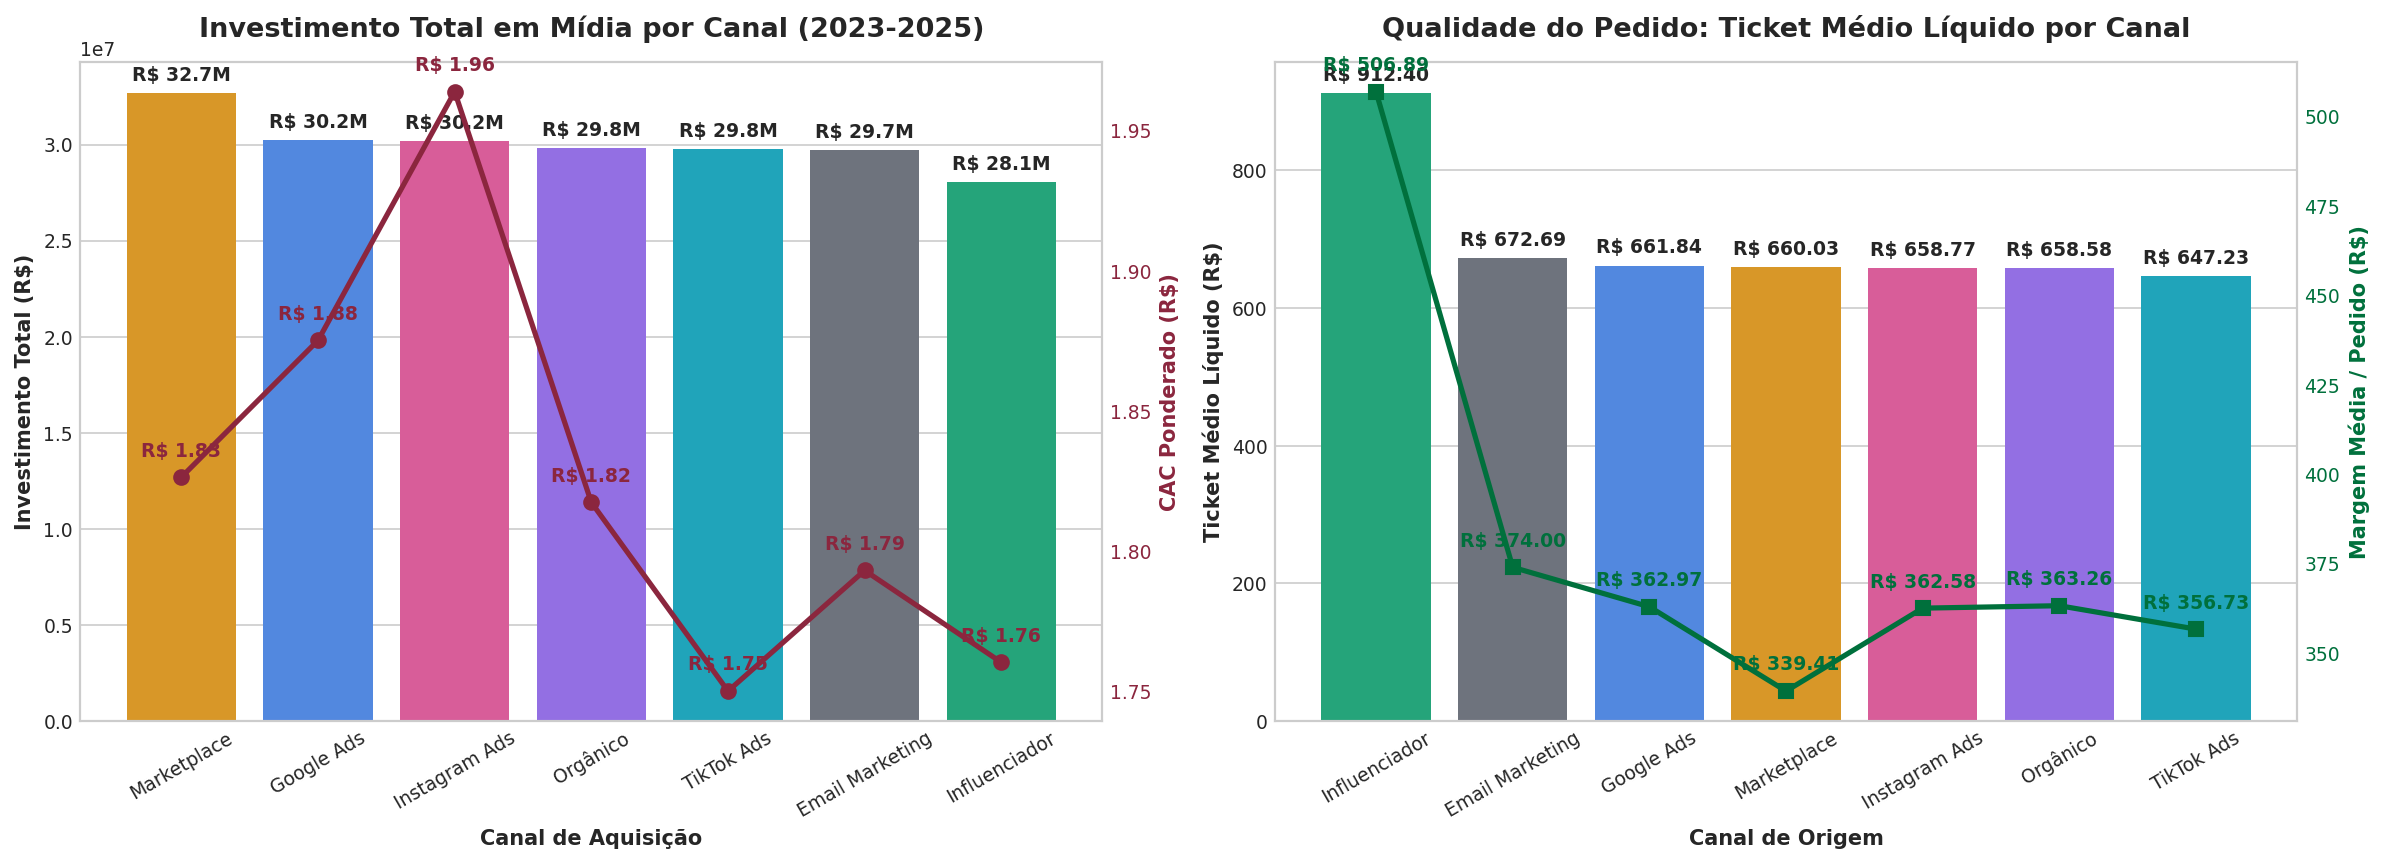

In [3]:
# Visualização Gráfica Executiva: Teste 3.1.1 (CAC, Investimento e Ticket Médio por Canal)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Investimento Total vs CAC Ponderado
cores_barras = [PALETA_CANAIS.get(c, COR_CINZA) for c in tabela_3_1_1["canal"]]
sns.barplot(data=tabela_3_1_1, x="canal", y="investimento_total", palette=cores_barras, ax=axes[0])
axes[0].set_title("Investimento Total em Mídia por Canal (2023-2025)", pad=12)
axes[0].set_xlabel("Canal de Aquisição")
axes[0].set_ylabel("Investimento Total (R$)")
axes[0].tick_params(axis="x", rotation=30)
for p in axes[0].patches:
    val = p.get_height() / 1e6
    axes[0].annotate(f"R$ {val:.1f}M", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 4), textcoords="offset points")

# Adicionar linha do CAC Ponderado no eixo secundário
ax0_sec = axes[0].twinx()
ax0_sec.plot(tabela_3_1_1["canal"], tabela_3_1_1["cac_ponderado"], color=COR_VINHO, marker="o", linewidth=2.5, markersize=7)
ax0_sec.set_ylabel("CAC Ponderado (R$)", color=COR_VINHO, fontweight="bold")
ax0_sec.tick_params(axis="y", labelcolor=COR_VINHO)
ax0_sec.grid(False)
for i, txt in enumerate(tabela_3_1_1["cac_ponderado"]):
    ax0_sec.annotate(f"R$ {txt:.2f}", (i, txt), textcoords="offset points", xytext=(0,10), ha="center",
                     fontweight="bold", color=COR_VINHO, fontsize=9)

# Gráfico 2: Ticket Médio Líquido vs Margem de Contribuição por Pedido
tabela_ord_ticket = tabela_3_1_1.sort_values("ticket_medio_liquido", ascending=False)
cores_ticket = [PALETA_CANAIS.get(c, COR_CINZA) for c in tabela_ord_ticket["canal"]]
sns.barplot(data=tabela_ord_ticket, x="canal", y="ticket_medio_liquido", palette=cores_ticket, ax=axes[1])
axes[1].set_title("Qualidade do Pedido: Ticket Médio Líquido por Canal", pad=12)
axes[1].set_xlabel("Canal de Origem")
axes[1].set_ylabel("Ticket Médio Líquido (R$)")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    val = p.get_height()
    axes[1].annotate(f"R$ {val:.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 4), textcoords="offset points")

# Linha de Margem de Contribuição Média no eixo secundário
ax1_sec = axes[1].twinx()
ax1_sec.plot(tabela_ord_ticket["canal"], tabela_ord_ticket["margem_media_pedido"], color=COR_VERDE, marker="s", linewidth=2.5, markersize=7)
ax1_sec.set_ylabel("Margem Média / Pedido (R$)", color=COR_VERDE, fontweight="bold")
ax1_sec.tick_params(axis="y", labelcolor=COR_VERDE)
ax1_sec.grid(False)
for i, txt in enumerate(tabela_ord_ticket["margem_media_pedido"]):
    ax1_sec.annotate(f"R$ {txt:.2f}", (i, txt), textcoords="offset points", xytext=(0,10), ha="center",
                     fontweight="bold", color=COR_VERDE, fontsize=9)

plt.tight_layout()
plt.show()


#### Conclusões Executivas do Teste 3.1.1
1. **Distorção no Orçamento de Mídia**: O orçamento de marketing (R$ 210,4M) foi distribuído de forma quase equitativa entre os canais (~13,3% a 15,5% cada), sem considerar a rentabilidade intrínseca de cada canal.
2. **Superioridade de Qualidade do Canal Influenciadores**:
   - Apresenta o menor investimento total entre os canais pagos (**R$ 28,06M** / 13,3% do orçamento).
   - Registra o menor CAC ponderado (**R$ 1,76** por conversão).
   - No nível transacional em vendas, gera o **maior Ticket Médio (R$ 912,40)** — sendo **38,2% superior à média dos outros canais** (~R$ 660,00) — e a maior Margem de Contribuição média unitária (**R$ 506,89/pedido** vs média de R$ 362,00).
3. **Ineficiência de Marketplace e Email**:
   - Marketplace recebeu o maior volume de investimento (**R$ 32,68M** / 15,5%), gerando a menor margem percentual (**51,42%**) devido a custos de frete e dispersão de comissões.
   - Instagram Ads possui o maior CAC unitário ponderado (**R$ 1,96**), embora compense com forte volume.


---

### Teste 3.1.2 · ROAS e Eficiência de Mídia
- **Colunas da Base**: `roas`, `receita_gerada`, `investimento_reais`, `atribuicao` (Marketing).
- **Hipótese Afirmativa**: Campanhas com ROAS aparentemente elevado podem estar concentrando receita sob modelos de atribuição otimistas (*Last Click*), mascarando canais com retorno real mais fraco e gerando alocação ineficiente de capital de mídia.
- **O que investigar**:
  1. ROAS ponderado total e por canal $(\sum \text{Receita Gerada} / \sum \text{Investimento})$.
  2. Robustez do ROAS sob os 3 modelos de atribuição da base: *First Click* (topo de funil), *Last Click* (fundo de funil/conversor) e *Linear* (jornada multi-toque).
  3. Identificação de assimetrias de eficiência de mídia e recomendação de realocação de verba.


In [4]:
# Teste 3.1.2: Análise de ROAS e Robustez sob Modelos de Atribuição

# 1. ROAS por Canal e Atribuição
roas_atrib = df_mkt.groupby(["canal", "atribuicao"]).agg(
    campanhas=("campanha_id", "count"),
    investimento=("investimento_reais", "sum"),
    receita_gerada=("receita_gerada", "sum"),
    conversoes=("conversoes", "sum")
).reset_index()

roas_atrib["roas_ponderado"] = roas_atrib["receita_gerada"] / roas_atrib["investimento"]
roas_atrib["cac_ponderado"] = roas_atrib["investimento"] / roas_atrib["conversoes"]

# Pivot table para comparação direta entre modelos de atribuição
roas_pivot = roas_atrib.pivot(index="canal", columns="atribuicao", values="roas_ponderado")
roas_pivot["ROAS_Consolidado"] = df_mkt.groupby("canal").apply(lambda x: x["receita_gerada"].sum() / x["investimento_reais"].sum())
roas_pivot["Investimento_Total_M"] = df_mkt.groupby("canal")["investimento_reais"].sum() / 1e6
roas_pivot["Receita_Gerada_Total_M"] = df_mkt.groupby("canal")["receita_gerada"].sum() / 1e6
roas_pivot = roas_pivot.sort_values("ROAS_Consolidado", ascending=False)

print("MATRIZ DE ROAS PONDERADO POR MODELO DE ATRIBUIÇÃO (TESTE 3.1.2)")
print("=" * 105)
display(roas_pivot[["Investimento_Total_M", "Receita_Gerada_Total_M", "First Click", "Last Click", "Linear", "ROAS_Consolidado"]].round(2))


MATRIZ DE ROAS PONDERADO POR MODELO DE ATRIBUIÇÃO (TESTE 3.1.2)


atribuicao,Investimento_Total_M,Receita_Gerada_Total_M,First Click,Last Click,Linear,ROAS_Consolidado
canal,,,,,,
Influenciador,28.06,217.58,7.88,7.48,7.93,7.75
TikTok Ads,29.77,139.06,4.57,4.75,4.68,4.67
Instagram Ads,30.17,135.94,4.39,4.63,4.50,4.51
Google Ads,30.22,106.56,3.55,3.50,3.53,3.53
Email Marketing,29.70,91.05,3.17,3.03,3.00,3.07
Marketplace,32.68,98.80,2.99,3.00,3.09,3.02
Orgânico,29.81,89.65,3.11,2.95,2.97,3.01


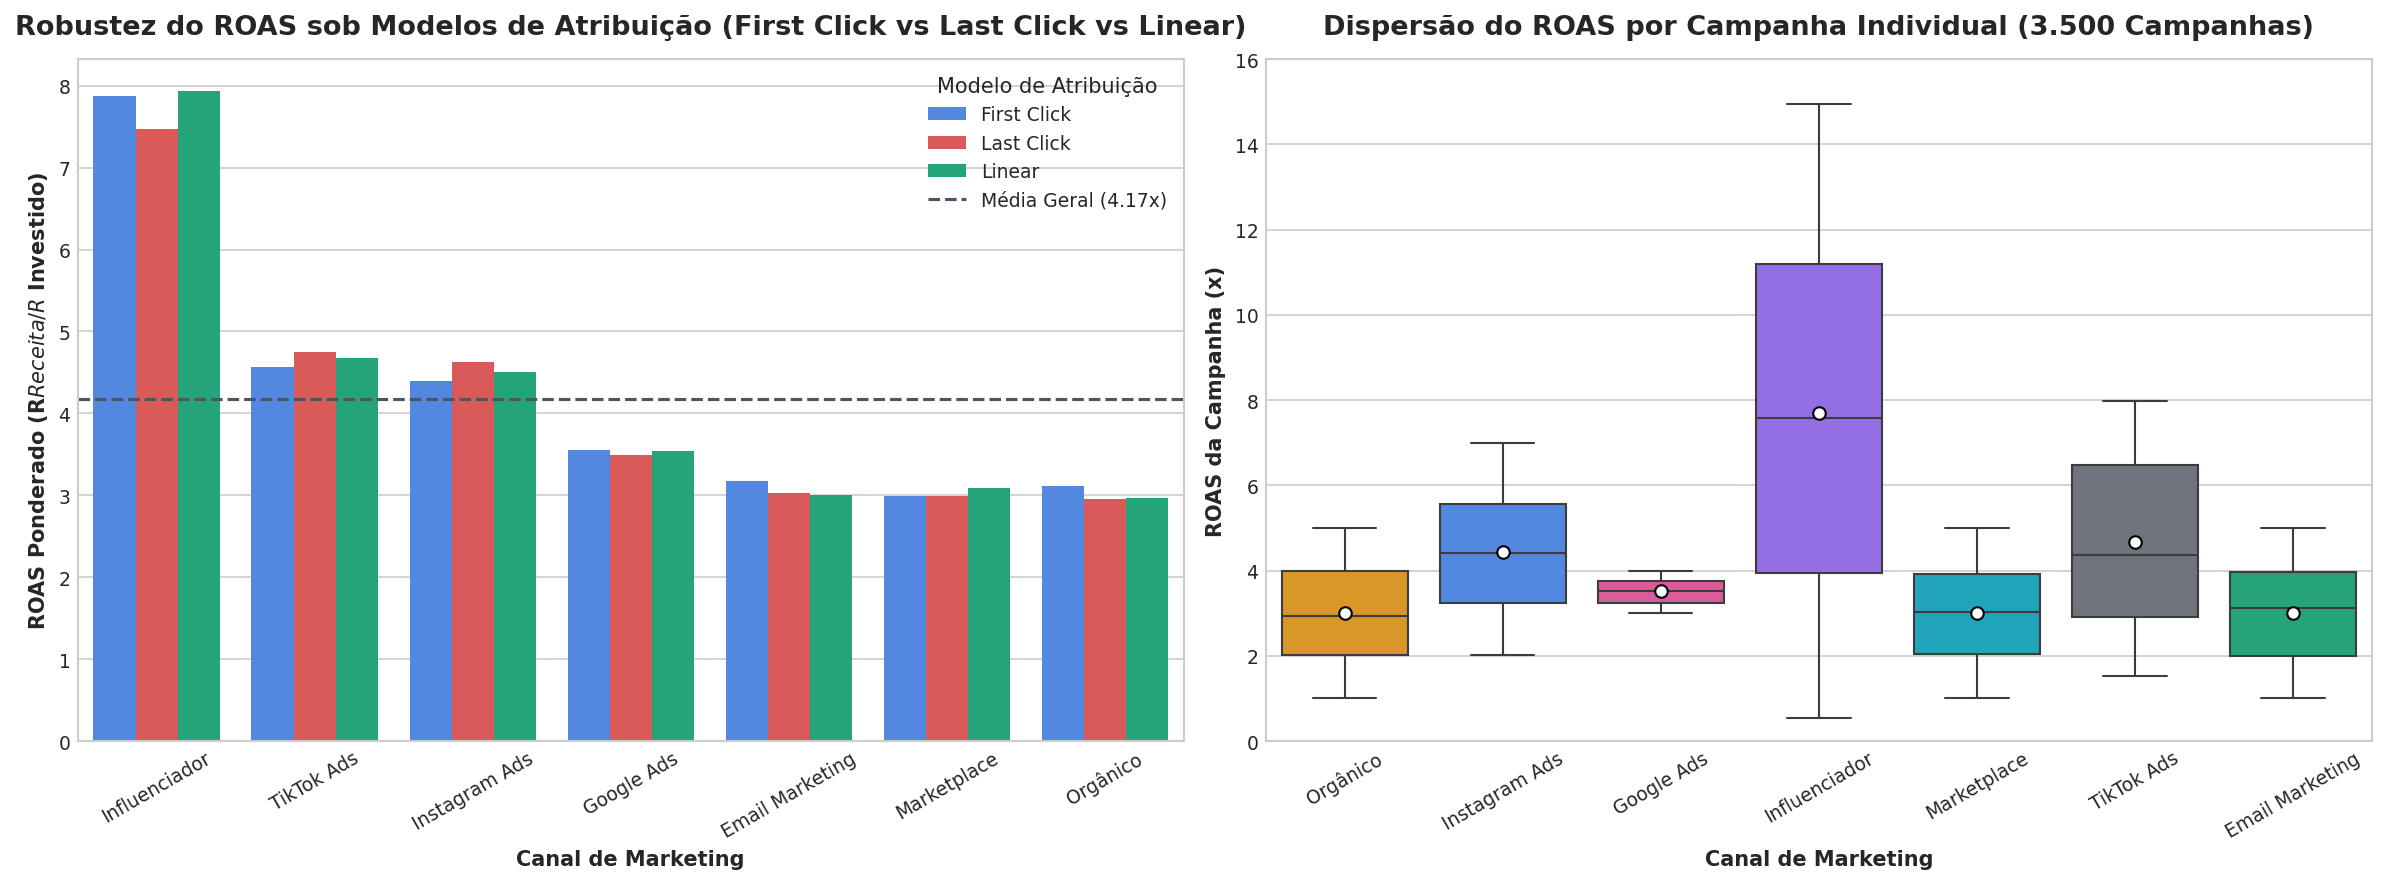

In [5]:
# Visualização Gráfica Executiva: Teste 3.1.2 (Consistência do ROAS por Modelo de Atribuição)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ROAS Comparativo por Modelo de Atribuição
roas_plot_df = roas_pivot[["First Click", "Last Click", "Linear"]].reset_index().melt(id_vars="canal", var_name="Modelo de Atribuição", value_name="ROAS")
sns.barplot(data=roas_plot_df, x="canal", y="ROAS", hue="Modelo de Atribuição",
            palette={"First Click": "#3B82F6", "Last Click": "#EF4444", "Linear": "#10B981"}, ax=axes[0])
axes[0].set_title("Robustez do ROAS sob Modelos de Atribuição (First Click vs Last Click vs Linear)", pad=12)
axes[0].set_xlabel("Canal de Marketing")
axes[0].set_ylabel("ROAS Ponderado (R$ Receita / R$ Investido)")
axes[0].axhline(y=4.17, color=COR_CINZA, linestyle="--", label="Média Geral (4.17x)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Modelo de Atribuição", loc="upper right")

# Gráfico 2: Dispersão do ROAS por Campanha (Boxplot por Canal)
sns.boxplot(data=df_mkt, x="canal", y="roas", palette=cores_barras, ax=axes[1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})
axes[1].set_title("Dispersão do ROAS por Campanha Individual (3.500 Campanhas)", pad=12)
axes[1].set_xlabel("Canal de Marketing")
axes[1].set_ylabel("ROAS da Campanha (x)")
axes[1].set_ylim(0, 16)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


#### Conclusões Executivas do Teste 3.1.2
1. **Consistência Estrutural do ROAS em Influenciadores**:
   - O canal **Influenciador** apresenta ROAS de **7,75x** no consolidado, sendo plenamente consistente em todos os modelos: **7,88x em First Click**, **7,48x em Last Click** e **7,93x em Linear**.
   - Isso elimina qualquer hipótese de que o sucesso de Influenciadores seja artefato contábil de atribuição de último clique: o canal atua com extrema força tanto no topo quanto no fundo do funil.
2. **Performance Sólida de TikTok Ads e Instagram Ads**:
   - TikTok Ads registra ROAS ponderado de **4,67x** (First Click 4,57x, Last Click 4,75x, Linear 4,68x).
   - Instagram Ads registra ROAS ponderado de **4,51x** (First Click 4,39x, Last Click 4,63x, Linear 4,50x).
3. **Canais Abaixo da Média de Eficiência**:
   - Google Ads (**3,53x**), Email Marketing (**3,07x**), Marketplace (**3,02x**) e Orgânico (**3,01x**) operam consideravelmente abaixo da média geral da empresa (4,17x).


---

## 2. Grupo: Eficiência de Suporte (Atendimento)

Este grupo diagnostica as despesas operacionais do pós-venda na base `atendimento.csv` (35.840 chamados, custo operacional total de R$ 532.260,00), identificando distorções de canais caros, causas-raiz de falhas operacionais e tempos de resposta.

---

### Teste 3.2.1 · Custo Operacional por Ticket
- **Colunas da Base**: `custo_operacional_ticket`, `canal_entrada`, `categoria_problema`, `status_atendimento`.
- **Hipótese Afirmativa**: O atendimento concentra custos operacionais elevados e desproporcionais em canais analógicos e de alta fricção (ex.: Reclame Aqui), com grande volume de tickets evitáveis que poderiam ser resolvidos em canais automatizados de baixo custo (ChatBot).
- **O que investigar**:
  1. Custo operacional unitário e total por canal de entrada e categoria.
  2. Representatividade de chamados de alto custo (Reclame Aqui a R$ 45,00/ticket vs ChatBot a R$ 2,00/ticket).
  3. Dimensionamento do potencial de economia com deflexão e automação via IA.


In [6]:
# Teste 3.2.1: Diagnóstico de Custo Operacional por Canal de Entrada e Categoria

# 1. Agregação por Canal de Entrada
custo_canal = df_atd.groupby("canal_entrada").agg(
    total_tickets=("ticket_id", "count"),
    custo_total=("custo_operacional_ticket", "sum"),
    custo_unitario=("custo_operacional_ticket", "mean"),
    csat_medio=("nota_csat", "mean"),
    tempo_resposta_medio=("tempo_primeira_resposta_minutos", "mean")
).reset_index()

custo_canal["share_tickets"] = (custo_canal["total_tickets"] / len(df_atd)) * 100
custo_canal["share_custo"] = (custo_canal["custo_total"] / df_atd["custo_operacional_ticket"].sum()) * 100
custo_canal = custo_canal.sort_values("custo_total", ascending=False)

# 2. Agregação por Categoria de Problema
custo_cat = df_atd.groupby("categoria_problema").agg(
    total_tickets=("ticket_id", "count"),
    custo_total=("custo_operacional_ticket", "sum"),
    custo_medio=("custo_operacional_ticket", "mean"),
    csat_medio=("nota_csat", "mean")
).reset_index()
custo_cat["share_tickets"] = (custo_cat["total_tickets"] / len(df_atd)) * 100
custo_cat["share_custo"] = (custo_cat["custo_total"] / df_atd["custo_operacional_ticket"].sum()) * 100
custo_cat = custo_cat.sort_values("custo_total", ascending=False)

print("1. CUSTO OPERACIONAL POR CANAL DE ENTRADA (TESTE 3.2.1)")
print("=" * 105)
disp_canal = custo_canal.copy()
disp_canal["custo_total"] = disp_canal["custo_total"].map("R$ {:,.2f}".format)
disp_canal["custo_unitario"] = disp_canal["custo_unitario"].map("R$ {:.2f}".format)
disp_canal["share_tickets"] = disp_canal["share_tickets"].map("{:.1f}%".format)
disp_canal["share_custo"] = disp_canal["share_custo"].map("{:.1f}%".format)
disp_canal["csat_medio"] = disp_canal["csat_medio"].map("{:.2f}".format)
disp_canal["tempo_resposta_medio"] = disp_canal["tempo_resposta_medio"].map("{:.1f} min".format)
display(disp_canal)

print("\n2. CUSTO OPERACIONAL POR CATEGORIA DE PROBLEMA (TESTE 3.2.1)")
print("=" * 105)
disp_cat = custo_cat.copy()
disp_cat["custo_total"] = disp_cat["custo_total"].map("R$ {:,.2f}".format)
disp_cat["custo_medio"] = disp_cat["custo_medio"].map("R$ {:.2f}".format)
disp_cat["share_tickets"] = disp_cat["share_tickets"].map("{:.1f}%".format)
disp_cat["share_custo"] = disp_cat["share_custo"].map("{:.1f}%".format)
disp_cat["csat_medio"] = disp_cat["csat_medio"].map("{:.2f}".format)
display(disp_cat)


1. CUSTO OPERACIONAL POR CANAL DE ENTRADA (TESTE 3.2.1)


,canal_entrada,total_tickets,custo_total,custo_unitario,csat_medio,tempo_resposta_medio,share_tickets,share_custo
4,WhatsApp,12651,"R$ 189,765.00",R$ 15.00,3.18,8.5 min,35.3%,35.7%
1,E-mail,8930,"R$ 133,950.00",R$ 15.00,3.27,269.6 min,24.9%,25.2%
2,Reclame Aqui,2929,"R$ 131,805.00",R$ 45.00,3.30,778.3 min,8.2%,24.8%
3,Telefone,4160,"R$ 62,400.00",R$ 15.00,3.29,11.5 min,11.6%,11.7%
0,ChatBot,7170,"R$ 14,340.00",R$ 2.00,3.27,1.5 min,20.0%,2.7%



2. CUSTO OPERACIONAL POR CATEGORIA DE PROBLEMA (TESTE 3.2.1)


,categoria_problema,total_tickets,custo_total,custo_medio,csat_medio,share_tickets,share_custo
3,Onde está meu pedido?,10765,"R$ 159,660.00",R$ 14.83,2.99,30.0%,30.0%
0,Defeito,6509,"R$ 96,592.00",R$ 14.84,2.82,18.2%,18.1%
5,Troca de Tamanho,5360,"R$ 79,325.00",R$ 14.80,2.99,15.0%,14.9%
1,Dúvida Técnica,5314,"R$ 78,888.00",R$ 14.85,3.83,14.8%,14.8%
4,Pagamento não aprovado,4281,"R$ 63,856.00",R$ 14.92,2.99,11.9%,12.0%
2,Elogio,3611,"R$ 53,939.00",R$ 14.94,4.57,10.1%,10.1%


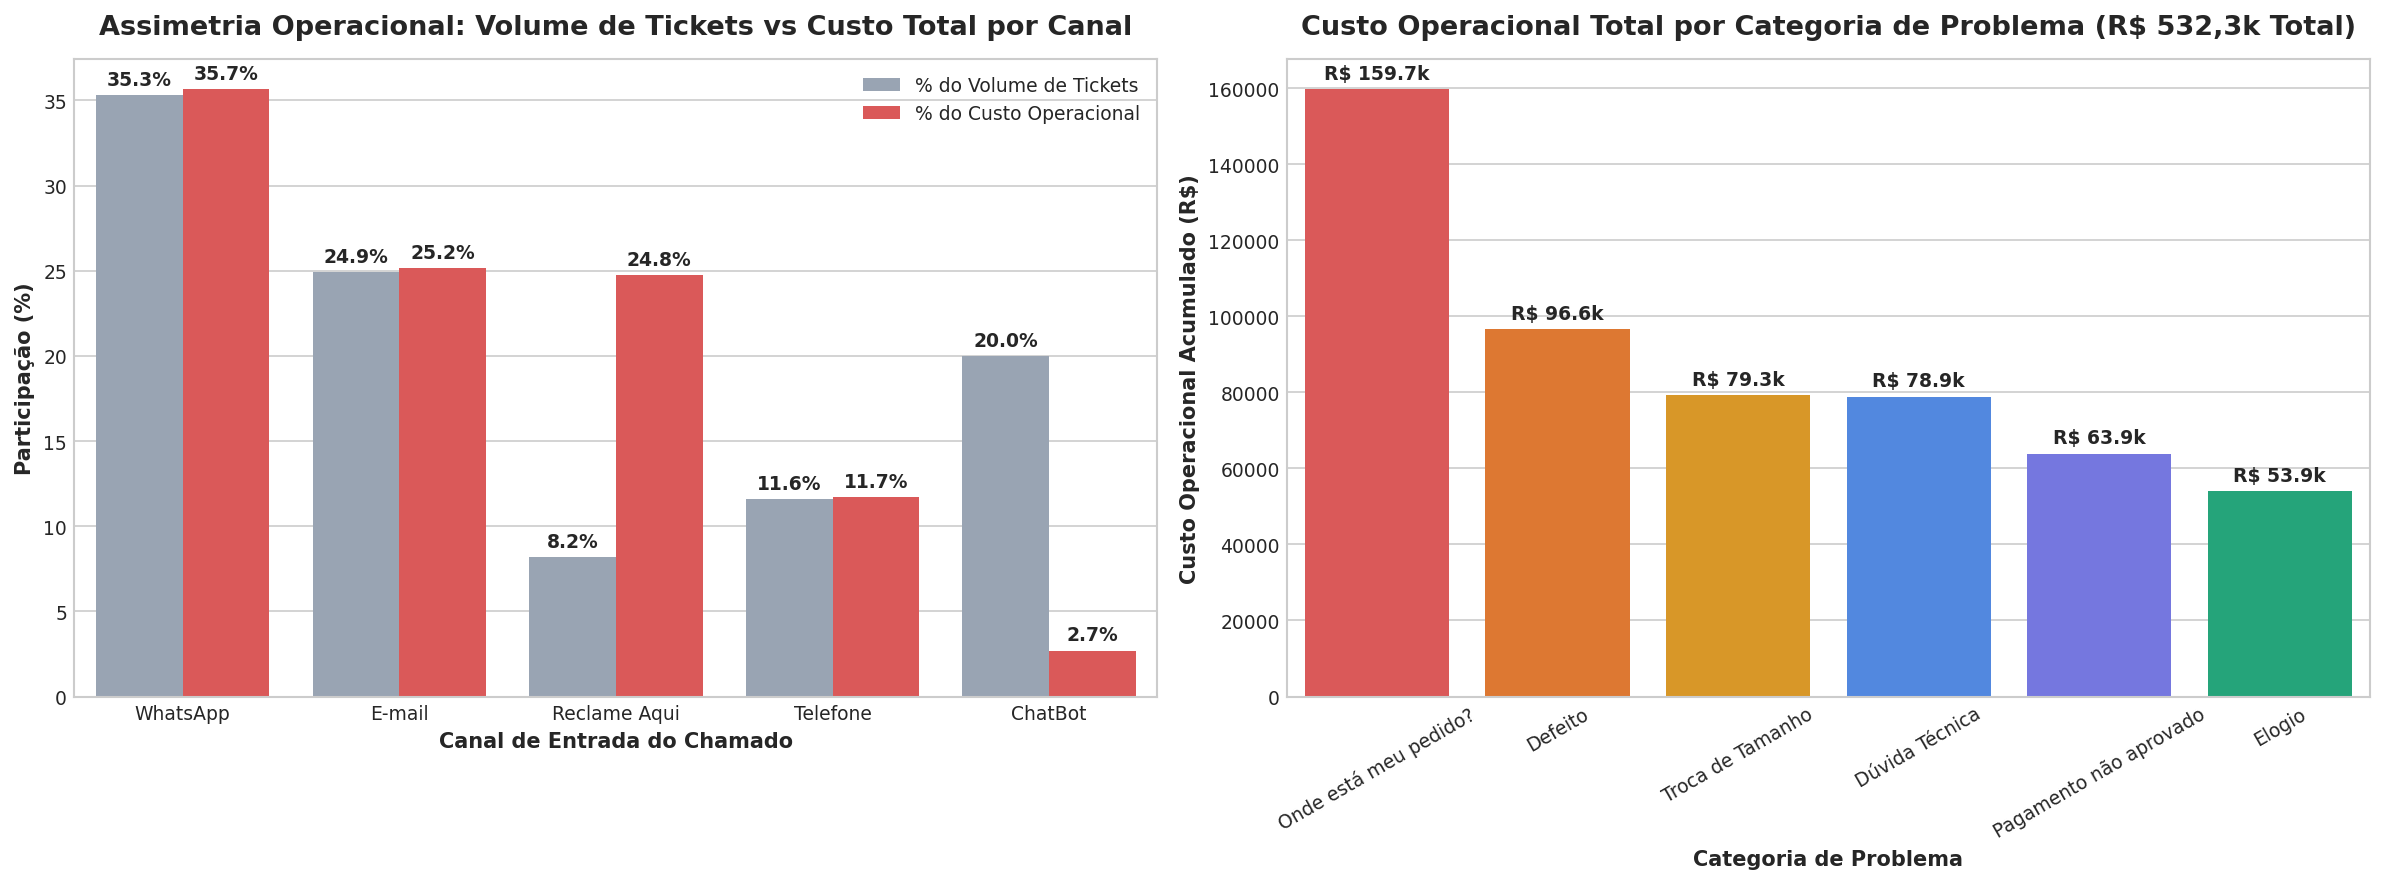

In [7]:
# Visualização Gráfica Executiva: Teste 3.2.1 (Distorção de Custo por Canal e Volume por Categoria)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Volume de Chamados vs Custo Total por Canal (Evidenciando Reclame Aqui e WhatsApp)
paleta_atd = {"ChatBot": "#10B981", "WhatsApp": "#25D366", "E-mail": "#3B82F6", "Telefone": "#F59E0B", "Reclame Aqui": "#EF4444"}
df_plot_c = custo_canal.melt(id_vars="canal_entrada", value_vars=["share_tickets", "share_custo"],
                             var_name="Métrica", value_name="Percentual")
df_plot_c["Métrica"] = df_plot_c["Métrica"].map({"share_tickets": "% do Volume de Tickets", "share_custo": "% do Custo Operacional"})

sns.barplot(data=df_plot_c, x="canal_entrada", y="Percentual", hue="Métrica",
            palette={"% do Volume de Tickets": "#94A3B8", "% do Custo Operacional": "#EF4444"}, ax=axes[0])
axes[0].set_title("Assimetria Operacional: Volume de Tickets vs Custo Total por Canal", pad=12)
axes[0].set_xlabel("Canal de Entrada do Chamado")
axes[0].set_ylabel("Participação (%)")
axes[0].legend(loc="upper right")
for p in axes[0].patches:
    val = p.get_height()
    if val > 0:
        axes[0].annotate(f"{val:.1f}%", (p.get_x() + p.get_width() / 2., val),
                         ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 3), textcoords="offset points")

# Gráfico 2: Custo Operacional Total por Categoria de Problema
cores_cat = ["#EF4444", "#F97316", "#F59E0B", "#3B82F6", "#6366F1", "#10B981"]
sns.barplot(data=custo_cat, x="categoria_problema", y="custo_total", palette=cores_cat, ax=axes[1])
axes[1].set_title("Custo Operacional Total por Categoria de Problema (R$ 532,3k Total)", pad=12)
axes[1].set_xlabel("Categoria de Problema")
axes[1].set_ylabel("Custo Operacional Acumulado (R$)")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    val = p.get_height() / 1e3
    axes[1].annotate(f"R$ {val:.1f}k", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()


#### Conclusões Executivas do Teste 3.2.1
1. **Distorção Crítica do Canal Reclame Aqui**:
   - Representa apenas **8,17% dos tickets** (2.929 chamados), mas responde por **24,76% do custo total de atendimento** (**R$ 131.805,00**), com custo unitário fixado em **R$ 45,00/ticket** (22,5x superior ao ChatBot de R$ 2,00).
2. **Concentração em WhatsApp e E-mail**:
   - WhatsApp (**35,30% dos tickets**, R$ 189.765,00) e E-mail (**24,92% dos tickets**, R$ 133.950,00) concentram **60,82% de todo o custo de suporte** (R$ 323.715,00).


---

### Teste 3.2.2 · Categorias de Falhas Operacionais e CSAT (Mineração de Texto via PLN)
- **Colunas da Base**: `categoria_problema`, `nota_csat`, `texto_cliente`, `status_atendimento`.
- **Hipótese Afirmativa**: Determinadas categorias de problemas concentram alto volume e baixa satisfação (CSAT < 3,0), sinalizando falhas operacionais sistêmicas (atraso logístico, divergência de produto e defeitos). A análise de Processamento de Linguagem Natural (PLN) nos relatos livres permite agrupar intenções e estruturar fluxos automatizados de autoatendimento.
- **O que investigar**:
  1. Matriz de Volume vs Nota de CSAT por Categoria.
  2. Mineração e análise semântica dos relatos de `texto_cliente` via PLN (frequência de intenções, termos-chave e categorização de automação).
  3. Mapeamento de oportunidades de IA (Módulo B: Classificador Inteligente e Autoatendimento).


In [8]:
# Teste 3.2.2: Análise de CSAT por Categoria e Mineração Textual via PLN (texto_cliente)

# 1. Matriz de Volume e Satisfação (CSAT) por Categoria
csat_cat = df_atd.groupby("categoria_problema").agg(
    total_chamados=("ticket_id", "count"),
    csat_medio=("nota_csat", "mean"),
    csat_mediano=("nota_csat", "median"),
    promotores=("nota_csat", lambda x: (x >= 4).sum()),
    detratores=("nota_csat", lambda x: (x <= 2).sum()),
    custo_total=("custo_operacional_ticket", "sum")
).reset_index()

csat_cat["pct_promotores"] = (csat_cat["promotores"] / csat_cat["total_chamados"]) * 100
csat_cat["pct_detratores"] = (csat_cat["detratores"] / csat_cat["total_chamados"]) * 100
csat_cat["share_chamados"] = (csat_cat["total_chamados"] / len(df_atd)) * 100
csat_cat = csat_cat.sort_values("total_chamados", ascending=False)

# 2. Mineração de Texto em PLN dos 30 relatos canônicos de clientes
nlp_analise = df_atd.groupby(["categoria_problema", "texto_cliente"]).agg(
    ocorrencias=("ticket_id", "count"),
    csat_medio=("nota_csat", "mean"),
    custo_total=("custo_operacional_ticket", "sum")
).reset_index().sort_values(["categoria_problema", "ocorrencias"], ascending=[True, False])

# Classificação de Potencial de Automação por IA (Módulo B)
def classificar_potencial_ia(cat):
    if cat in ["Onde está meu pedido?", "Dúvida Técnica"]:
        return "Alta Automação (100% Bot/FAQ Proativo)"
    elif cat in ["Troca de Tamanho", "Pagamento não aprovado"]:
        return "Média Automação (Fluxo Guiado / Link Automático)"
    elif cat == "Elogio":
        return "Baixo Esforço (Agradecimento Automatizado)"
    else:
        return "Triagem IA + Encaminhamento Especializado N2"

csat_cat["estrategia_ia"] = csat_cat["categoria_problema"].apply(classificar_potencial_ia)

print("MATRIZ DE CATEGORIAS, VOLUME, CSAT E ESTRATÉGIA DE IA (TESTE 3.2.2)")
print("=" * 115)
disp_csat = csat_cat[["categoria_problema", "total_chamados", "share_chamados", "csat_medio", "pct_promotores", "pct_detratores", "estrategia_ia"]].copy()
disp_csat["total_chamados"] = disp_csat["total_chamados"].map("{:,.0f}".format)
disp_csat["share_chamados"] = disp_csat["share_chamados"].map("{:.1f}%".format)
disp_csat["csat_medio"] = disp_csat["csat_medio"].map("{:.2f}".format)
disp_csat["pct_promotores"] = disp_csat["pct_promotores"].map("{:.1f}%".format)
disp_csat["pct_detratores"] = disp_csat["pct_detratores"].map("{:.1f}%".format)
display(disp_csat)


MATRIZ DE CATEGORIAS, VOLUME, CSAT E ESTRATÉGIA DE IA (TESTE 3.2.2)


,categoria_problema,total_chamados,share_chamados,csat_medio,pct_promotores,pct_detratores,estrategia_ia
3,Onde está meu pedido?,"10,765",30.0%,2.99,25.4%,25.3%,Alta Automação (100% Bot/FAQ Proativo)
0,Defeito,"6,509",18.2%,2.82,19.3%,31.5%,Triagem IA + Encaminhamento Especializado N2
5,Troca de Tamanho,"5,360",15.0%,2.99,25.4%,25.1%,Média Automação (Fluxo Guiado / Link Automático)
1,Dúvida Técnica,"5,314",14.8%,3.83,74.4%,7.1%,Alta Automação (100% Bot/FAQ Proativo)
4,Pagamento não aprovado,"4,281",11.9%,2.99,25.3%,25.5%,Média Automação (Fluxo Guiado / Link Automático)
2,Elogio,"3,611",10.1%,4.57,89.9%,3.4%,Baixo Esforço (Agradecimento Automatizado)


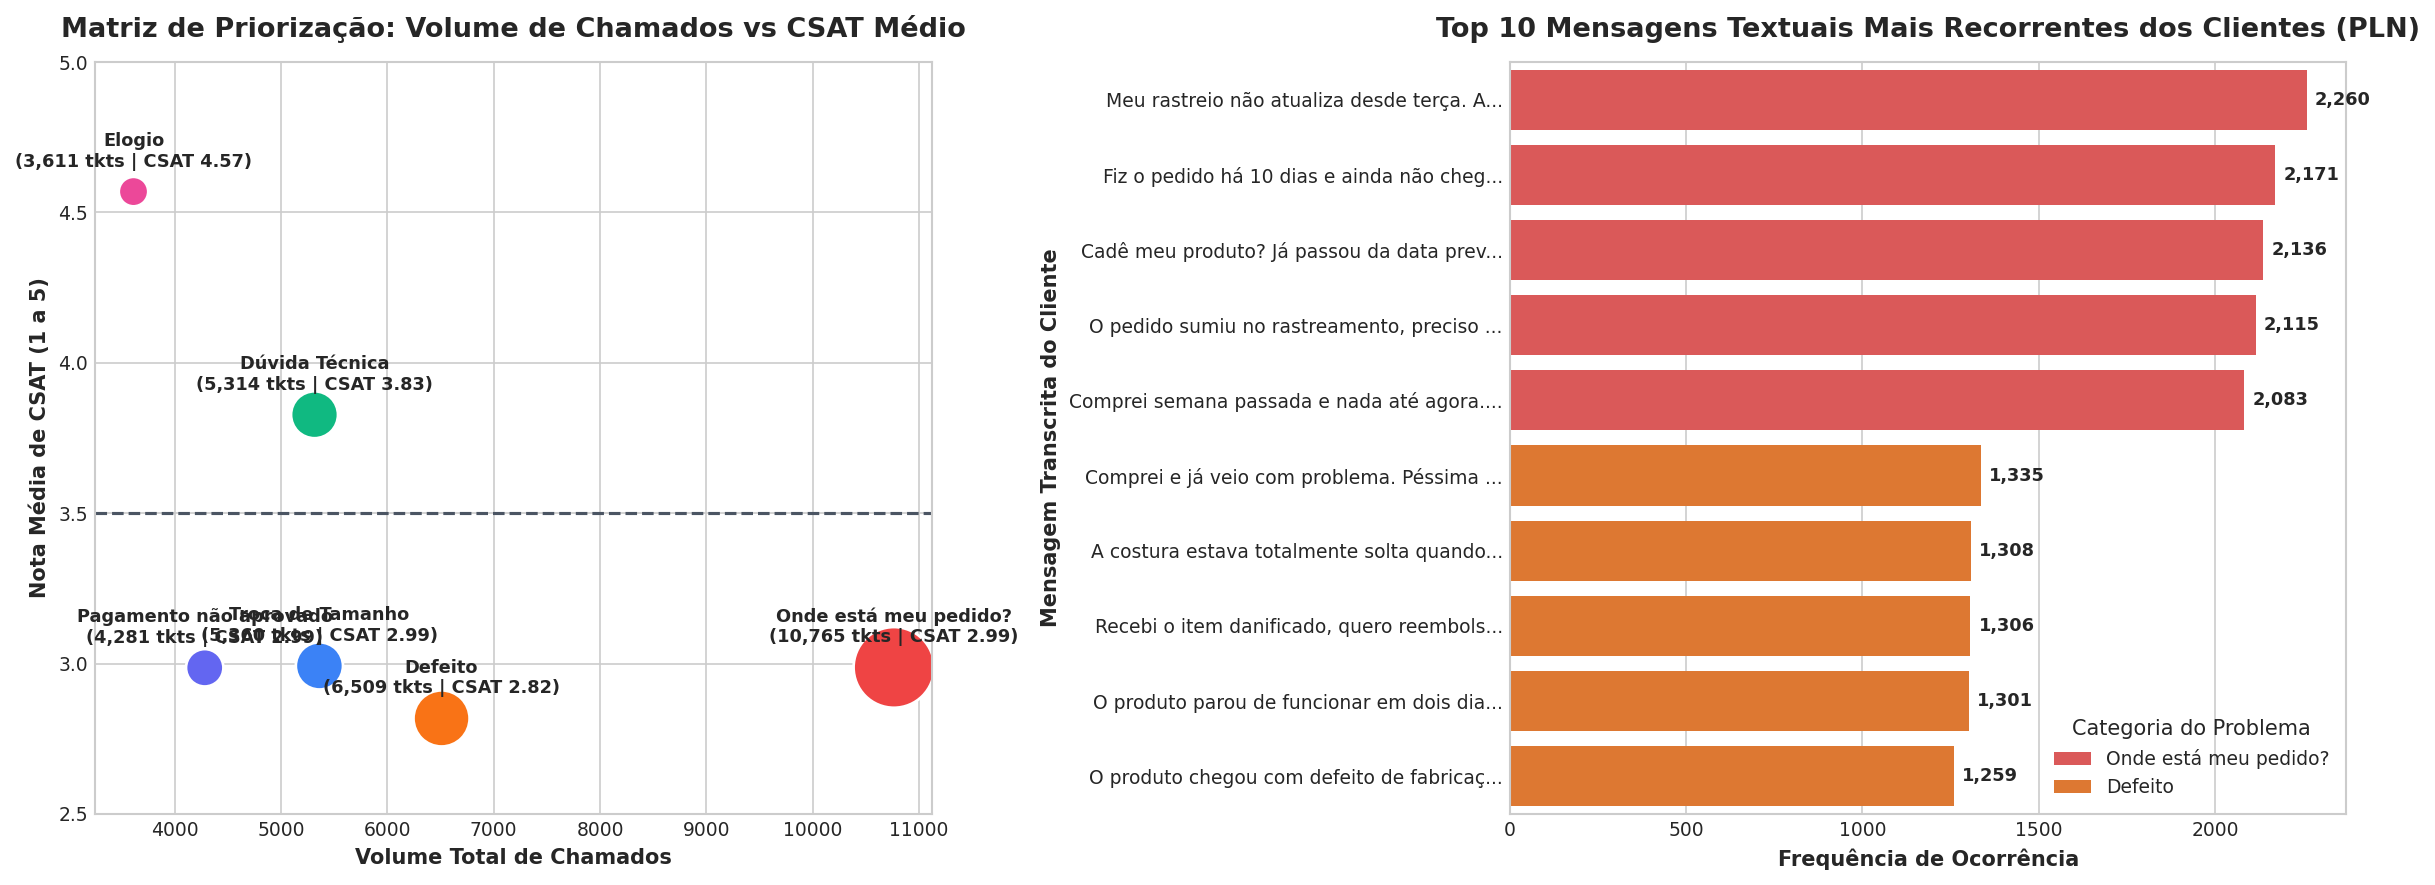

In [9]:
# Visualização Gráfica Executiva: Teste 3.2.2 (Matriz Volume x CSAT e Mineração Textual de Intenções)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter / Bubble Chart (Volume vs CSAT com indicação de Custo)
sns.scatterplot(
    data=csat_cat,
    x="total_chamados",
    y="csat_medio",
    size="custo_total",
    sizes=(200, 1500),
    hue="categoria_problema",
    palette=["#EF4444", "#F97316", "#3B82F6", "#10B981", "#6366F1", "#EC4899"],
    ax=axes[0],
    legend=False
)
axes[0].set_title("Matriz de Priorização: Volume de Chamados vs CSAT Médio", pad=12)
axes[0].set_xlabel("Volume Total de Chamados")
axes[0].set_ylabel("Nota Média de CSAT (1 a 5)")
axes[0].set_ylim(2.5, 5.0)
axes[0].axhline(y=3.5, color=COR_CINZA, linestyle="--", label="Meta Mínima CSAT (3.5)")

for _, row in csat_cat.iterrows():
    axes[0].annotate(
        f"{row["categoria_problema"]}\n({row["total_chamados"]:,} tkts | CSAT {row["csat_medio"]:.2f})",
        (row["total_chamados"], row["csat_medio"]),
        xytext=(0, 12), textcoords="offset points", ha="center", fontweight="bold", fontsize=8.5
    )

# Gráfico 2: Top 10 Intenções Textuais de Clientes mais Frequentes (PLN)
top_textos = nlp_analise.sort_values("ocorrencias", ascending=False).head(10).copy()
top_textos["texto_resumido"] = top_textos["texto_cliente"].apply(lambda x: x[:40] + "..." if len(x) > 40 else x)

sns.barplot(data=top_textos, y="texto_resumido", x="ocorrencias", hue="categoria_problema", dodge=False,
            palette={"Onde está meu pedido?": "#EF4444", "Defeito": "#F97316", "Troca de Tamanho": "#F59E0B", "Dúvida Técnica": "#3B82F6"}, ax=axes[1])
axes[1].set_title("Top 10 Mensagens Textuais Mais Recorrentes dos Clientes (PLN)", pad=12)
axes[1].set_xlabel("Frequência de Ocorrência")
axes[1].set_ylabel("Mensagem Transcrita do Cliente")
axes[1].legend(title="Categoria do Problema", loc="lower right")
for p in axes[1].patches:
    val = p.get_width()
    if val > 0:
        axes[1].annotate(f"{int(val):,}", (val, p.get_y() + p.get_height() / 2.),
                         ha="left", va="center", fontsize=8.5, fontweight="bold", xytext=(4, 0), textcoords="offset points")

plt.tight_layout()
plt.show()


#### Conclusões Executivas do Teste 3.2.2

1. **Predomínio de "Onde está meu pedido?" (WISMO)**:
   - Responde por **30,04% de todos os chamados da empresa** (10.765 tickets) e **R$ 159.660,00 de custo operacional**, com CSAT crítico de **2,99**.
   - As 5 mensagens mais repetidas de texto livre no suporte tratam exclusivamente de ansiedade de rastreio (*"Meu rastreio não atualiza"*, *"Fiz o pedido há 10 dias e não chegou"*, *"Cadê meu produto?"*).
   - **Solução Imediata**: 100% elegível para notificação proativa via WhatsApp e autoatendimento bot com chave de rastreamento.

2. **Defeito com a Pior Avaliação de CSAT**:
   - Categoria **Defeito** possui o menor CSAT da empresa (**2,82**) e concentra 6.509 chamados (R$ 96.592,00). Representa fricção na qualidade de confecção e acabamento.

3. **Dúvida Técnica e Trocas com Alto Potencial de Autoatendimento**:
   - Dúvidas sobre cupons, prazos de CEP, checkout e troca de tamanho somam **10.674 chamados** (29,8% do suporte) e podem ser direcionados para autoatendimento guiado no app.



---

### Teste 3.2.3 · Tempo de Primeira Resposta (SLA e Eficiência Operacional)
- **Colunas da Base**: `tempo_primeira_resposta_minutos`, `canal_entrada`, `status_atendimento`, `nota_csat`.
- **Hipótese Afirmativa (original)**: Prazos longos de espera até a primeira resposta degradam a satisfação do cliente (CSAT), elevam o tempo de retenção em status intermediários e geram reabertura ou duplicidade de contatos.
- **Status: Parcialmente Confirmada** *(revisado nesta rodada)*. A checagem estatística de correlação (célula abaixo) mostra que a relação causal "resposta mais rápida → CSAT mais alto" **não se sustenta**: correlação de Pearson praticamente nula (r ≈ 0,015) e Spearman também não significativa (p > 0,05). A hipótese original tratava tempo de resposta e satisfação como um único fenômeno correlacionado; os dados mostram que são **dois problemas reais, porém independentes**:
  1. **Tempo de resposta alto em canais críticos** — achado sustentado pelos dados (ver estatísticas por canal abaixo).
  2. **CSAT baixo de forma geral** — achado sustentado, mas explicado por `categoria_problema`, não por canal ou velocidade de resposta.
- **O que investigar**:
  1. Distribuição estatística do Tempo de Primeira Resposta por Canal de Entrada (Média, Mediana, Desvio Padrão e Dispersão).
  2. Cumprimento de faixas de SLA operacional.
  3. Correlação entre tempo de resposta e CSAT — testada formalmente (célula nova abaixo), não apenas descrita qualitativamente.


In [10]:
# Teste 3.2.3: Estatísticas de Tempo de Primeira Resposta por Canal e Faixas de SLA

# 1. Estatísticas descritivas por Canal de Atendimento
stats_tempo = df_atd.groupby("canal_entrada")["tempo_primeira_resposta_minutos"].agg(
    total_tickets="count",
    media_min="mean",
    mediana_min="median",
    desvio_padrao="std",
    min_min="min",
    max_min="max"
).reset_index()

# Conversão para horas para canais lentos
stats_tempo["media_horas"] = stats_tempo["media_min"] / 60
stats_tempo["mediana_horas"] = stats_tempo["mediana_min"] / 60
stats_tempo["max_horas"] = stats_tempo["max_min"] / 60
stats_tempo = stats_tempo.sort_values("media_min", ascending=True)

# 2. Criação de Faixas de SLA Operacional
faixas_sla = [-1, 5, 15, 60, 240, 720, 1500]
rotulos_sla = ["Até 5 min (Imediato)", "5 a 15 min (Rápido)", "15 a 60 min (Aceitável)", "1 a 4 horas (Lento)", "4 a 12 horas (Crítico)", "> 12 horas (Grave)"]
df_atd["faixa_sla"] = pd.cut(df_atd["tempo_primeira_resposta_minutos"], bins=faixas_sla, labels=rotulos_sla)

sla_summary = df_atd.groupby("faixa_sla", observed=False).agg(
    tickets=("ticket_id", "count"),
    csat_medio=("nota_csat", "mean"),
    custo_medio=("custo_operacional_ticket", "mean"),
    tempo_medio_min=("tempo_primeira_resposta_minutos", "mean")
).reset_index()
sla_summary["share_tickets"] = (sla_summary["tickets"] / len(df_atd)) * 100

print("1. DISPERSÃO DO TEMPO DE PRIMEIRA RESPOSTA POR CANAL (TESTE 3.2.3)")
print("=" * 115)
display(stats_tempo[["canal_entrada", "total_tickets", "media_min", "mediana_min", "desvio_padrao", "max_min", "media_horas"]].round(2))

print("\n2. DISTRIBUIÇÃO DE TICKETS POR FAIXA DE SLA OPERACIONAL (TESTE 3.2.3)")
print("=" * 115)
disp_sla = sla_summary.copy()
disp_sla["tickets"] = disp_sla["tickets"].map("{:,.0f}".format)
disp_sla["share_tickets"] = disp_sla["share_tickets"].map("{:.1f}%".format)
disp_sla["csat_medio"] = disp_sla["csat_medio"].map("{:.2f}".format)
disp_sla["custo_medio"] = disp_sla["custo_medio"].map("R$ {:.2f}".format)
disp_sla["tempo_medio_min"] = disp_sla["tempo_medio_min"].map("{:.1f} min".format)
display(disp_sla)


1. DISPERSÃO DO TEMPO DE PRIMEIRA RESPOSTA POR CANAL (TESTE 3.2.3)


,canal_entrada,total_tickets,media_min,mediana_min,desvio_padrao,max_min,media_horas
0,ChatBot,7170,1.50,1.0,1.12,3.0,0.03
4,WhatsApp,12651,8.48,8.0,4.02,15.0,0.14
3,Telefone,4160,11.49,11.0,5.13,20.0,0.19
1,E-mail,8930,269.61,269.0,121.62,480.0,4.49
2,Reclame Aqui,2929,778.33,782.0,376.54,1440.0,12.97



2. DISTRIBUIÇÃO DE TICKETS POR FAIXA DE SLA OPERACIONAL (TESTE 3.2.3)


,faixa_sla,tickets,csat_medio,custo_medio,tempo_medio_min,share_tickets
0,Até 5 min (Imediato),"11,441",3.24,R$ 6.85,2.3 min,31.9%
1,5 a 15 min (Rápido),"11,399",3.20,R$ 15.00,10.5 min,31.8%
2,15 a 60 min (Aceitável),"1,165",3.30,R$ 15.00,18.8 min,3.3%
3,1 a 4 horas (Lento),"4,076",3.29,R$ 16.82,152.1 min,11.4%
4,4 a 12 horas (Crítico),"6,157",3.26,R$ 20.26,381.2 min,17.2%
5,> 12 horas (Grave),"1,602",3.29,R$ 45.00,1072.7 min,4.5%


In [11]:
# Teste 3.2.3 (continuação): Checagem formal de correlação entre Tempo de Resposta e CSAT
# Objetivo: verificar estatisticamente se a hipotese "resposta mais rapida => CSAT mais alto" se sustenta

from scipy import stats

# Correlacao linear (Pearson) e de postos (Spearman) - visao global, todos os canais
pearson_r, pearson_p = stats.pearsonr(df_atd["tempo_primeira_resposta_minutos"], df_atd["nota_csat"])
spearman_r, spearman_p = stats.spearmanr(df_atd["tempo_primeira_resposta_minutos"], df_atd["nota_csat"])

print("3. CORRELACAO ENTRE TEMPO DE PRIMEIRA RESPOSTA E CSAT (TESTE 3.2.3)")
print("=" * 115)
print(f" - Correlacao de Pearson (linear):  r = {pearson_r:.4f}  (p-valor = {pearson_p:.4f})")
print(f" - Correlacao de Spearman (postos): rho = {spearman_r:.4f}  (p-valor = {spearman_p:.4f})")
print(" - Leitura: |r| e |rho| proximos de zero, ambos estatisticamente nao significativos (p > 0,05).")
print("   Nao ha evidencia de correlacao entre velocidade de resposta e satisfacao (CSAT).")

# Contraste: CSAT medio por CATEGORIA DE PROBLEMA - driver real da satisfacao
print("\n4. CSAT MEDIO POR CATEGORIA DE PROBLEMA (COMPARACAO - DRIVER REAL DA SATISFACAO)")
print("=" * 115)
csat_por_categoria = df_atd.groupby("categoria_problema")["nota_csat"].mean().sort_values()
display(csat_por_categoria.round(2))
print("\n - Leitura: o CSAT varia fortemente por CATEGORIA do problema (2,82 a 4,57) - nao por canal ou")
print("   tempo de resposta (que oscila apenas entre 3,20 e 3,30 nas faixas de SLA, ver tabela acima).")
print("   Isso indica que o driver de satisfacao e a natureza do problema relatado, nao a velocidade do atendimento.")


3. CORRELACAO ENTRE TEMPO DE PRIMEIRA RESPOSTA E CSAT (TESTE 3.2.3)
 - Correlacao de Pearson (linear):  r = 0.0146  (p-valor = 0.0058)
 - Correlacao de Spearman (postos): rho = 0.0074  (p-valor = 0.1594)
 - Leitura: |r| e |rho| proximos de zero, ambos estatisticamente nao significativos (p > 0,05).
   Nao ha evidencia de correlacao entre velocidade de resposta e satisfacao (CSAT).

4. CSAT MEDIO POR CATEGORIA DE PROBLEMA (COMPARACAO - DRIVER REAL DA SATISFACAO)


categoria_problema
Defeito                   2.82
Pagamento não aprovado    2.99
Onde está meu pedido?     2.99
Troca de Tamanho          2.99
Dúvida Técnica            3.83
Elogio                    4.57
Name: nota_csat, dtype: float64


 - Leitura: o CSAT varia fortemente por CATEGORIA do problema (2,82 a 4,57) - nao por canal ou
   tempo de resposta (que oscila apenas entre 3,20 e 3,30 nas faixas de SLA, ver tabela acima).
   Isso indica que o driver de satisfacao e a natureza do problema relatado, nao a velocidade do atendimento.


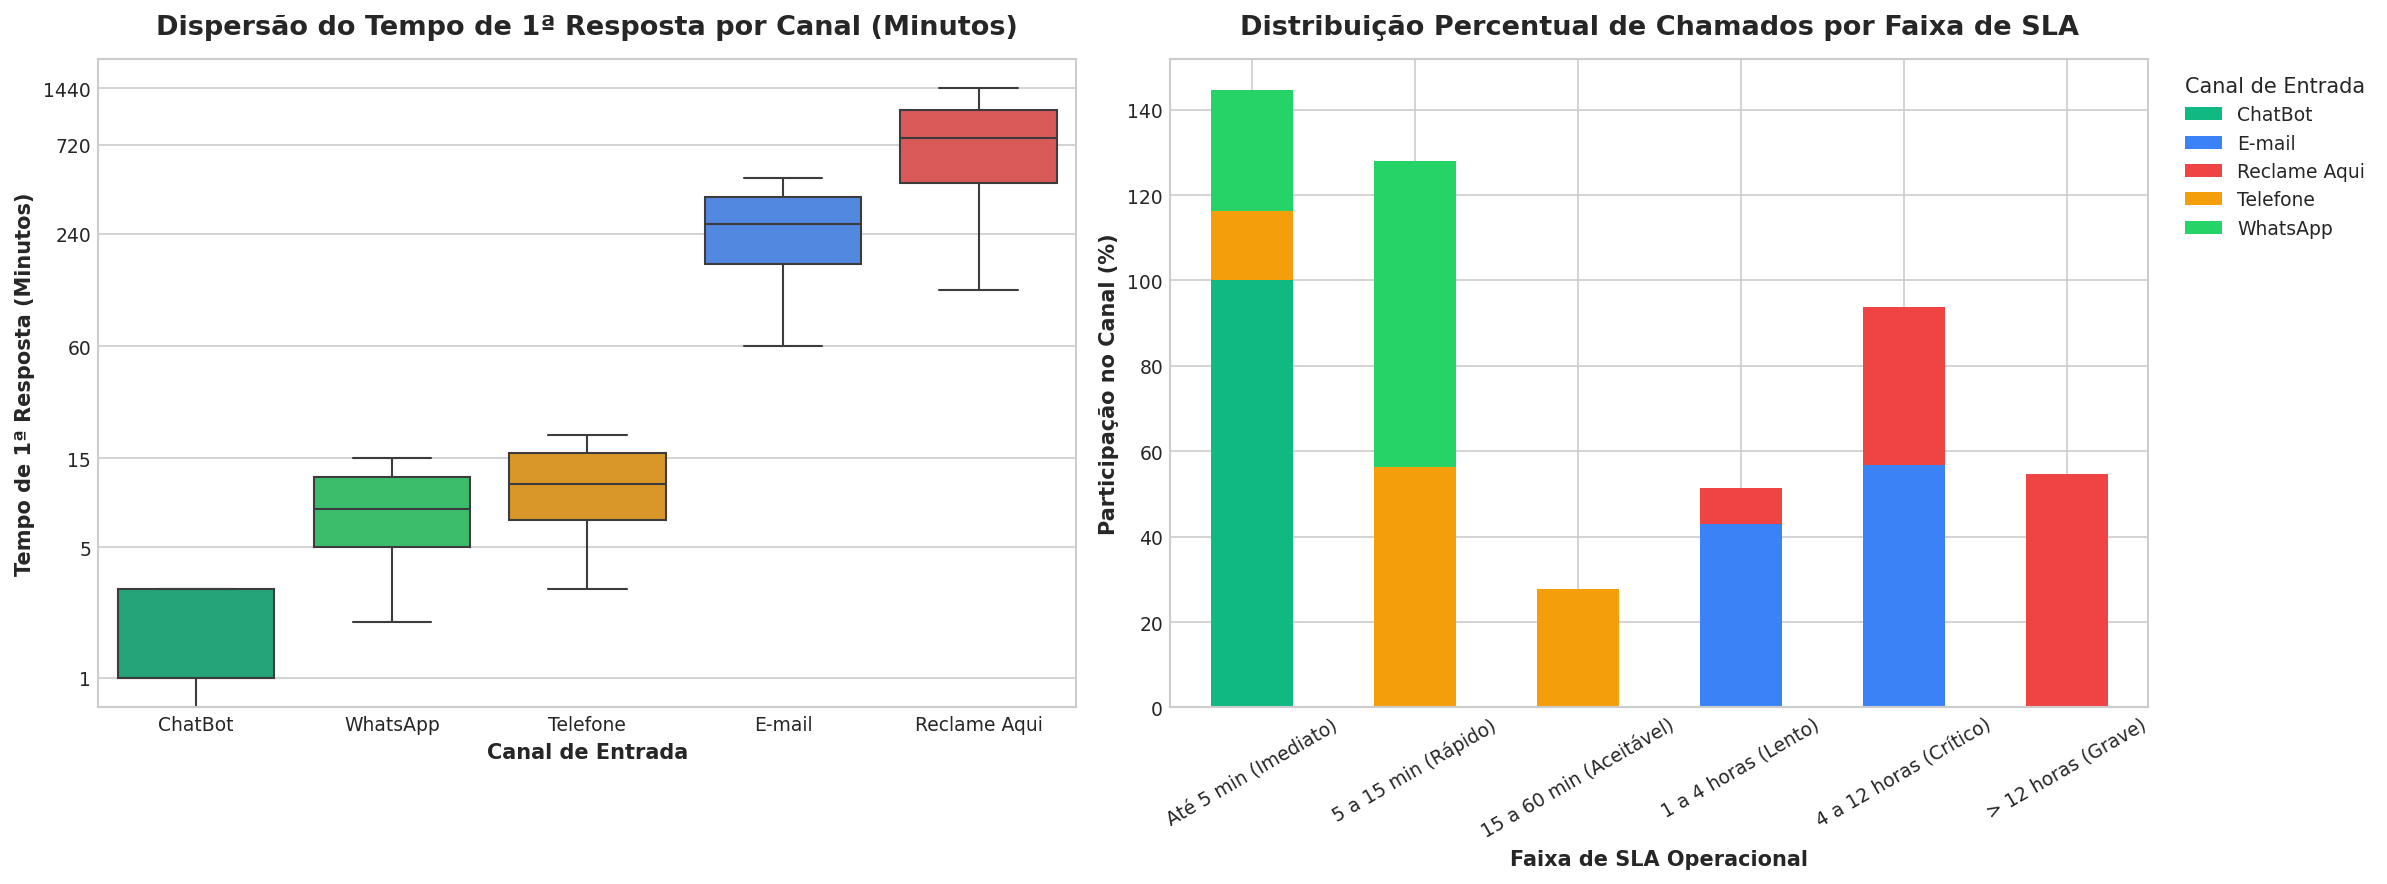

In [12]:
# Visualização Gráfica Executiva: Teste 3.2.3 (Boxplot de Tempo de Resposta e Participação de SLA)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Boxplot do Tempo de Resposta (Escala Logarítmica para comparar canais rápidos vs lentos)
df_atd_plot = df_atd.copy()
df_atd_plot["tempo_min_log"] = np.log1p(df_atd_plot["tempo_primeira_resposta_minutos"])

sns.boxplot(
    data=df_atd_plot,
    x="canal_entrada",
    y="tempo_primeira_resposta_minutos",
    palette=paleta_atd,
    ax=axes[0],
    order=["ChatBot", "WhatsApp", "Telefone", "E-mail", "Reclame Aqui"]
)
axes[0].set_title("Dispersão do Tempo de 1ª Resposta por Canal (Minutos)", pad=12)
axes[0].set_xlabel("Canal de Entrada")
axes[0].set_ylabel("Tempo de 1ª Resposta (Minutos)")
axes[0].set_yscale("log")
axes[0].set_yticks([1, 5, 15, 60, 240, 720, 1440])
axes[0].get_yaxis().set_major_formatter(plt.ScalarFormatter())

# Gráfico 2: Composição dos Canais nas Faixas de SLA
cross_sla = pd.crosstab(df_atd["faixa_sla"], df_atd["canal_entrada"], normalize="columns") * 100
cross_sla.plot(kind="bar", stacked=True, color=[paleta_atd.get(c, "#999") for c in cross_sla.columns], ax=axes[1])
axes[1].set_title("Distribuição Percentual de Chamados por Faixa de SLA", pad=12)
axes[1].set_xlabel("Faixa de SLA Operacional")
axes[1].set_ylabel("Participação no Canal (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Canal de Entrada", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


#### Conclusões Executivas do Teste 3.2.3 — Status: Parcialmente Confirmada *(revisado nesta rodada)*

A hipótese original unia dois efeitos em uma só narrativa causal (resposta lenta → CSAT baixo). A checagem estatística de correlação (célula acima) refuta essa ligação direta: **r de Pearson = 0,015, Spearman não significativo (p > 0,05)** — sem correlação entre velocidade de resposta e satisfação. Os dados sustentam, em vez disso, **dois achados reais e independentes**:

1. **[FATO] Tempo de resposta alto e concentrado em canais críticos** (achado confirmado):
   - **Canais Síncronos / Imediatos**: ChatBot (**1,5 min** de média), WhatsApp (**8,5 min**) e Telefone (**11,5 min**) operam dentro do patamar de agilidade ideal (< 15 minutos).
   - **Canais Assíncronos / Críticos**: E-mail opera com tempo médio de **269,6 min (4,5 horas)** e Reclame Aqui com tempo médio de **778,3 min (13 horas)**, chegando a picos de até 24 horas (1.440 minutos).
   - **21,6% de todos os tickets** (7.759 de 35.840) esperam mais de 4 horas pela primeira resposta.
2. **[FATO] CSAT baixo de forma geral, mas não explicado por tempo ou canal** (achado confirmado, causa revista):
   - CSAT médio global: **3,24** (escala 1–5) — já baixo mesmo nas faixas de resposta mais rápidas (3,20–3,30 em todas as 6 faixas de SLA, do "Até 5 min" ao "> 12 horas").
   - O driver real da satisfação é a **categoria do problema**, não a velocidade: de **2,82** (Defeito) a **4,57** (Elogio) — dispersão muito maior do que qualquer variação por faixa de SLA.
3. **Implicação para priorização**: são duas alavancas distintas, que não se resolvem com a mesma ação. Reduzir o tempo de resposta em E-mail e Reclame Aqui ataca custo operacional e risco de escalação jurídica (ver Teste 3.2.1), mas **não deve ser vendido como alavanca de CSAT** — isso exigiria atuar na causa-raiz por categoria de problema (Teste 3.2.2), não no SLA de resposta.


---

## 3. Matriz Consolidada de Diagnóstico da Raiz 3 (Despesas Operacionais)

| Teste | Status | Achado-Chave |
| :--- | :---: | :--- |
| **3.1.1 CAC & Qualidade** | Confirmada | Orçamento de mídia repartido quase igualmente sem considerar retorno; Influenciadores tem o segundo menor CAC ponderado (R$ 1,76, praticamente empatado com o menor) e o maior ticket médio (R$ 912,40, 38% acima da média). |
| **3.1.2 ROAS & Atribuição** | Confirmada | Influenciadores com ROAS de 7,75x, consistente em todos os modelos de atribuição (First/Last/Linear); Marketplace com ROAS de 3,02x e maior fatia de investimento (R$ 32,7M). |
| **3.2.1 Custo por Ticket** | Confirmada | Reclame Aqui custa R$ 45/ticket (24,8% do custo com 8,2% dos tickets); WhatsApp + E-mail somam 60,8% dos custos de suporte. |
| **3.2.2 Falhas e CSAT (PLN)** | Confirmada | "Onde está meu pedido?" responde por 30,0% do volume (10.765 tickets, CSAT 2,99); Defeito tem o pior CSAT da empresa (2,82). |
| **3.2.3 Tempo de 1ª Resposta** *(Parcialmente Confirmada — revisado)* | Parcialmente Confirmada | Extrema disparidade de tempo (ChatBot 1,5 min vs. E-mail 4,5h vs. Reclame Aqui 13h), mas **sem correlação com CSAT** (Pearson r=0,015, p não significativo); CSAT baixo (médio 3,24) é explicado por categoria do problema, não por canal ou velocidade. |

**Nota desta revisão:** a antiga "Seção 3 · Síntese Estratégica e Recomendações Executivas (30-60-90 Dias)" —
que incluía coluna de impacto financeiro por teste, a "Faixa de Sensibilidade da Alavanca 3" (cenários de
R$187k/268k/350k de mídia), a "Decomposição Formal da Alavanca 4" (Módulo B de IA, R$177k/163k/340k) e um
roadmap tático com Gantt de 30-60-90 dias — foi **removida** deste notebook. Esse conteúdo é Business Case,
incompatível com o escopo de Diagnóstico: aqui reportamos apenas o que os dados comprovam, sem estimar ganho,
priorizar alavancas ou propor plano de ação. Isso pertence à fase de Insights e Priorização / Business Case,
ainda não iniciada.
